In [9]:
import pandas as pd
import re
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('../data/raw/Studytime26.csv')

def parse_jp_date(date_str):
    #1月5日 → 2026-01-05
    if pd.isna(date_str) or date_str is np.nan:
        return pd.NaT
    date_str = str(date_str).strip()
    match = re.match(r'(\d+)月(\d+)日', date_str)
    if match:
        month, day = int(match.group(1)), int(match.group(2))
        return pd.Timestamp(2026, month, day)  # 年固定（変えたい年はここ）
    return pd.NaT

df['date'] = df['date'].apply(parse_jp_date)
print(df[['date', 'day']].head(10))

        date  day
0 2026-01-05  Mon
1 2026-01-06  Tue
2 2026-01-07  Wed
3 2026-01-07  Wed
4 2026-01-08  Thu
5 2026-01-08  Thu
6 2026-01-08  Thu
7 2026-01-11  Sun
8 2026-01-12  Mon
9 2026-01-26  Mon


In [12]:
def parse_duration(dur_str):
    if pd.isna(dur_str):
        return 0
    dur_str = str(dur_str).strip().rstrip('分')
    if ':' in dur_str:
        h, m = map(int, dur_str.split(':'))
        return h * 60 + m
    else:
        return int(dur_str)

df['duration_min'] = df['duration'].apply(parse_duration)
print(df[['duration', 'duration_min']].head())

  duration  duration_min
0     2:00           120
1     1:00            60
2     1:00            60
3     3:47           227
4     4:44           284


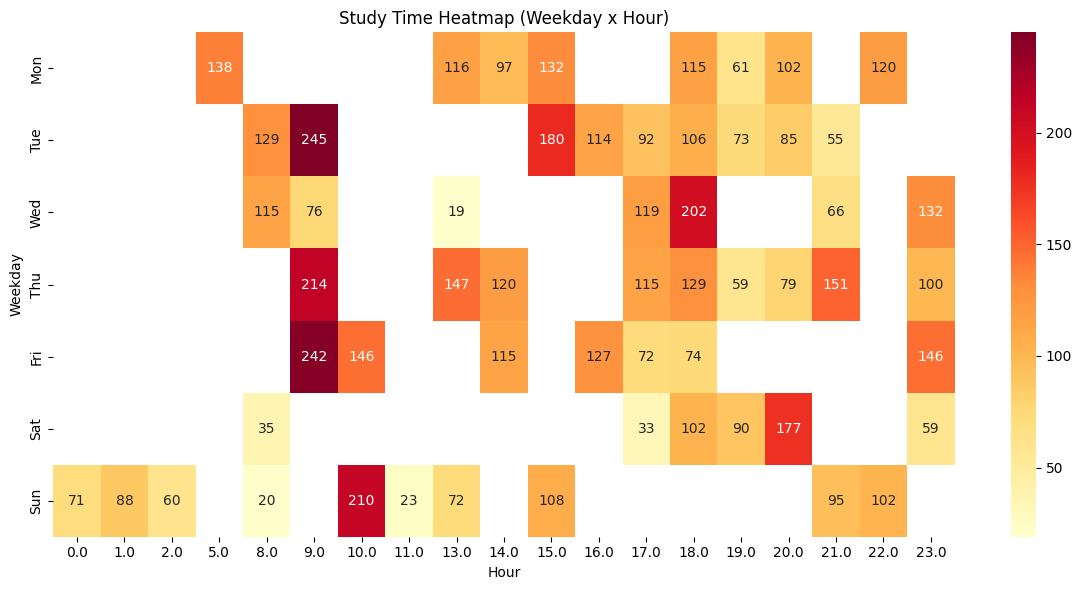

In [15]:
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
df['day'] = pd.Categorical(df['day'], categories=day_order, ordered=True)
df['hour'] = pd.to_datetime(df['time'], format='%H:%M').dt.hour

pivot = df.pivot_table(index='day', columns='hour', values='duration_min', aggfunc='mean')

plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, cmap='YlOrRd', fmt='.0f')
plt.title('Study Time Heatmap (Weekday x Hour)')
plt.xlabel('Hour'); plt.ylabel('Weekday')
plt.tight_layout(); 
plt.savefig('../figures/Studytime_heatmap.png', dpi=300, bbox_inches='tight', facecolor='white')
plt.show()